# 03 · Exploratory Data Analysis
Distributions, outliers, breakdowns by era, position, type, and artist tier.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
df = pd.read_csv('../data/processed/normalized.csv')
df_valid = df.dropna(subset=['composite_delta_30g'])
print(f"Analyzing {len(df_valid)} complete mentions")


Analyzing 140 complete mentions


C:\Users\User\AppData\Local\Temp\ipykernel_27488\3303307441.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Compliment', 'Neutral', 'Diss'],
C:\Users\User\AppData\Local\Temp\ipykernel_27488\3303307441.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Compliment', 'Neutral', 'Diss'],
C:\Users\User\AppData\Local\Temp\ipykernel_27488\3303307441.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Compliment', 'Neutral', 'Diss'],


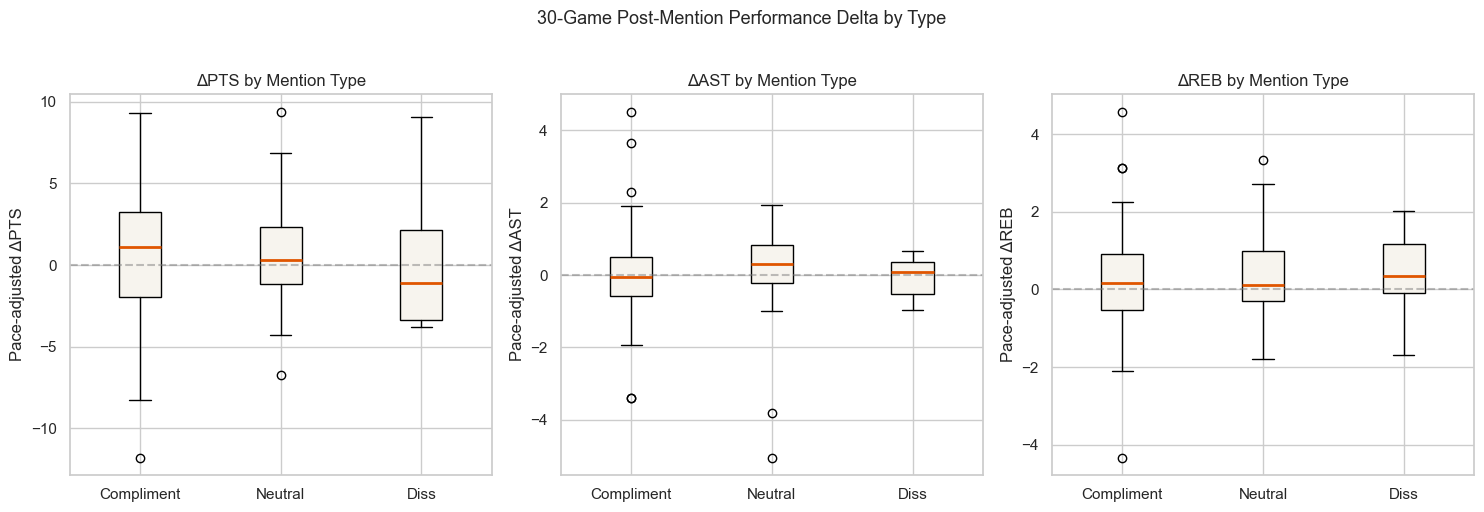

In [2]:
# 1. Breakdown by mention type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stats = ['PTS', 'AST', 'REB']
for ax, stat in zip(axes, stats):
    col = f'delta_after_30g_{stat}_adj'
    data = [df_valid[df_valid['mention_type']==t][col].dropna() for t in ['compliment','neutral','diss']]
    ax.boxplot(data, labels=['Compliment', 'Neutral', 'Diss'],
               patch_artist=True,
               boxprops=dict(facecolor='#F7F4EE'),
               medianprops=dict(color='#E05500', linewidth=2))
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Δ{stat} by Mention Type')
    ax.set_ylabel(f'Pace-adjusted Δ{stat}')
plt.suptitle('30-Game Post-Mention Performance Delta by Type', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_by_type.png', dpi=150)
plt.show()


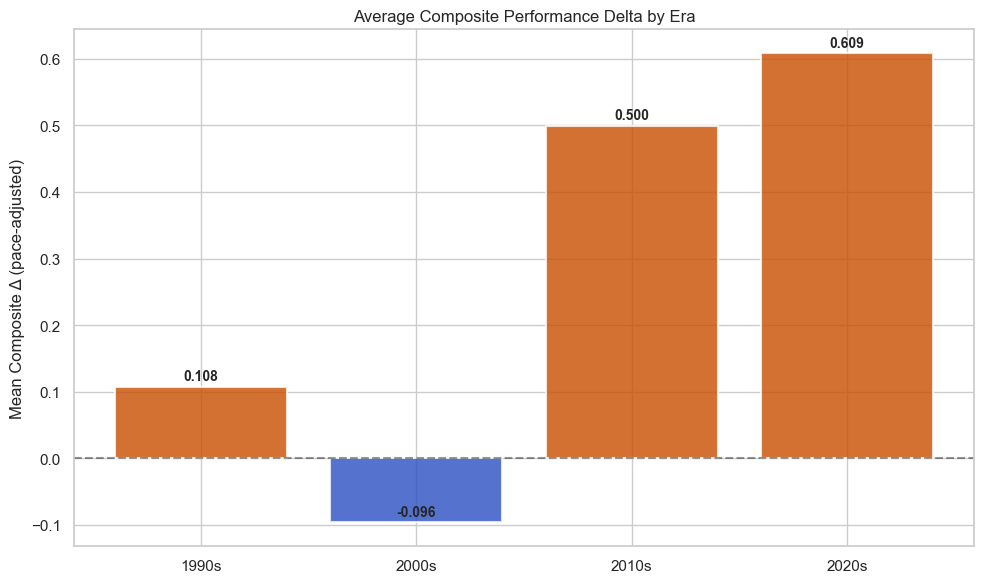

In [3]:
# 2. By era
fig, ax = plt.subplots(figsize=(10, 6))
era_means = df_valid.groupby('era')['composite_delta_30g'].mean().sort_index()
colors = ['#C84E00' if v > 0 else '#2B4FC4' for v in era_means.values]
bars = ax.bar(era_means.index, era_means.values, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.set_title('Average Composite Performance Delta by Era')
ax.set_ylabel('Mean Composite Δ (pace-adjusted)')
for bar, val in zip(bars, era_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, val + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_by_era.png', dpi=150)
plt.show()


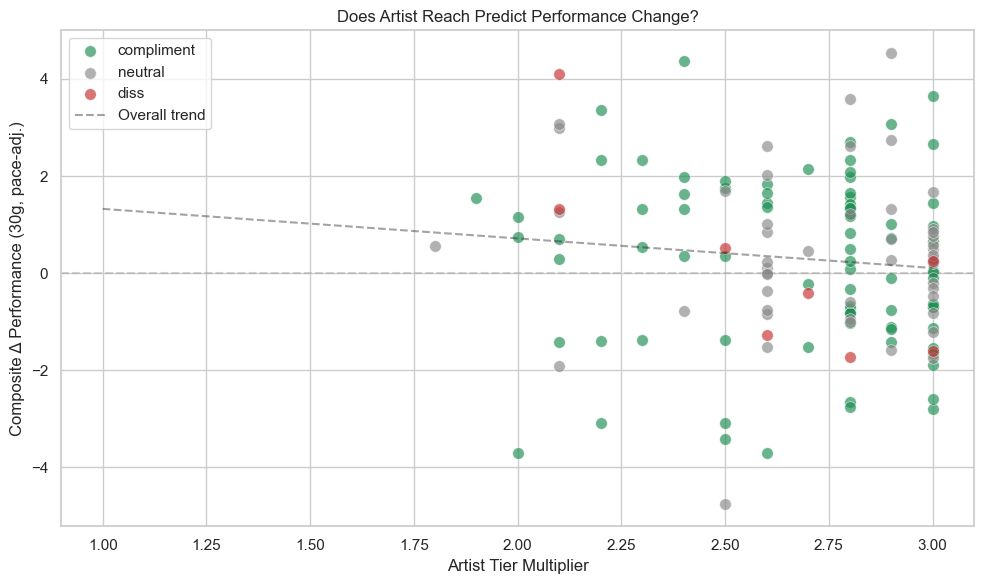

In [4]:
# 3. Artist tier vs composite delta (scatter)
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'compliment': '#1A8C50', 'neutral': '#888', 'diss': '#C42B2B'}
for t in ['compliment', 'neutral', 'diss']:
    sub = df_valid[df_valid['mention_type'] == t]
    ax.scatter(sub['artist_tier'], sub['composite_delta_30g'],
               label=t, color=colors[t], alpha=0.65, s=70, edgecolors='white', linewidths=0.5)
# Trend line
z = np.polyfit(df_valid['artist_tier'].dropna(), df_valid['composite_delta_30g'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(1, 3, 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.4, linewidth=1.5, label='Overall trend')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Artist Tier Multiplier')
ax.set_ylabel('Composite Δ Performance (30g, pace-adj.)')
ax.set_title('Does Artist Reach Predict Performance Change?')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_tier_scatter.png', dpi=150)
plt.show()


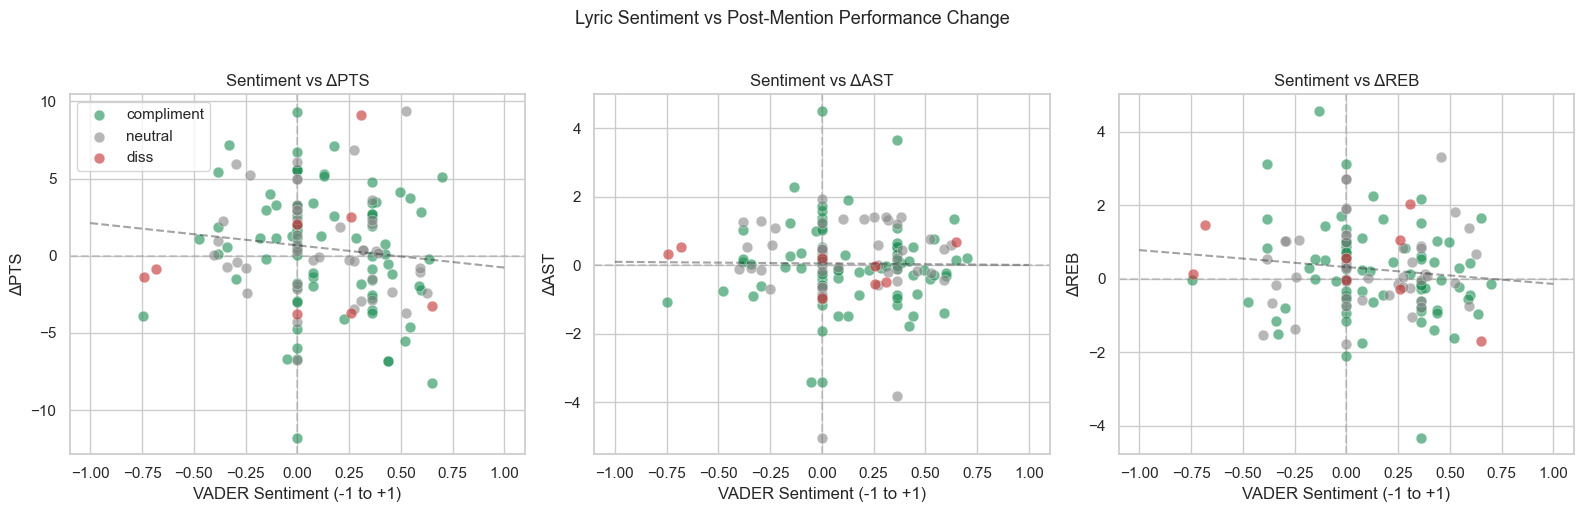

In [5]:
# 4. Sentiment vs delta (scatter) — the key plot
if 'vader_compound' in df_valid.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, stat in zip(axes, ['PTS', 'AST', 'REB']):
        col = f'delta_after_30g_{stat}_adj'
        sub = df_valid[['vader_compound', col, 'mention_type']].dropna()
        for t in ['compliment', 'neutral', 'diss']:
            s = sub[sub['mention_type'] == t]
            ax.scatter(s['vader_compound'], s[col], label=t,
                       color=colors[t], alpha=0.6, s=60, edgecolors='white', linewidths=0.4)
        z = np.polyfit(sub['vader_compound'], sub[col], 1)
        x_line = np.linspace(-1, 1, 100)
        ax.plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.4, linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
        ax.set_xlabel('VADER Sentiment (-1 to +1)')
        ax.set_ylabel(f'Δ{stat}')
        ax.set_title(f'Sentiment vs Δ{stat}')
    axes[0].legend()
    plt.suptitle('Lyric Sentiment vs Post-Mention Performance Change', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/processed/eda_sentiment_scatter.png', dpi=150)
    plt.show()


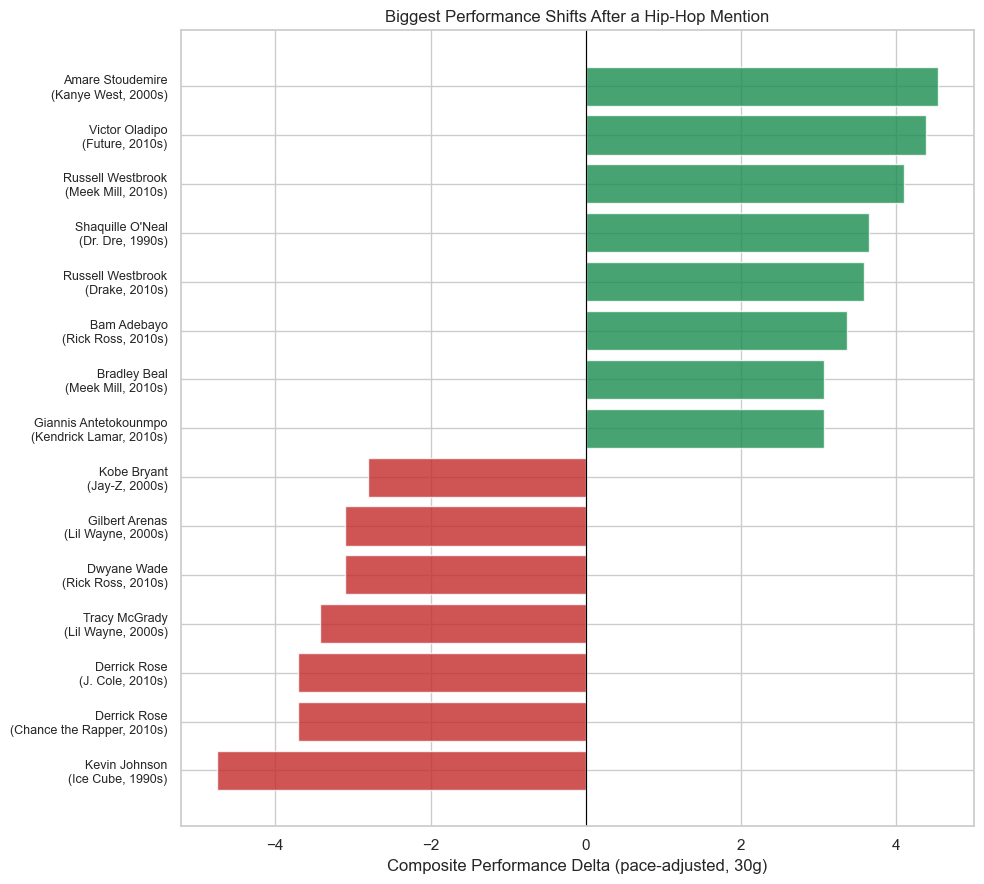

In [6]:
# 5. Top 15 biggest impacts (both directions)
top = df_valid.nlargest(8, 'composite_delta_30g')
bot = df_valid.nsmallest(7, 'composite_delta_30g')
top_df = pd.concat([top, bot]).sort_values('composite_delta_30g', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ['#1A8C50' if v > 0 else '#C42B2B' for v in top_df['composite_delta_30g']]
labels = [f"{r['player']}\n({r['artist']}, {r['era']})" for _, r in top_df.iterrows()]
ax.barh(range(len(top_df)), top_df['composite_delta_30g'], color=colors_bar, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Composite Performance Delta (pace-adjusted, 30g)')
ax.set_title('Biggest Performance Shifts After a Hip-Hop Mention')
plt.tight_layout()
plt.savefig('../data/processed/eda_top_impacts.png', dpi=150)
plt.show()
